In [2]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# WEIGHTS

In [3]:
slope_weight = 0.2
dtw_weight = 0.2
peatland_weight = 0.2
deposits_weight = 0.2
canopy_weight = 0.2
road_weight = 0.2
water_weight = 0.2

# SLOPE

In [4]:
# open SLOPE
slope_path = "Layers/Slope_merged.tif"

with rasterio.open(slope_path) as src:
    
    slope = src.read(1)  # first band
    profile = src.profile
    nodata = src.nodata

print("Shape:", slope.shape)
print("Min:", np.nanmin(slope))
print("Max:", np.nanmax(slope))
print("NoData:", nodata)

Shape: (10520, 8194)
Min: 0.0
Max: 59.53125
NoData: None


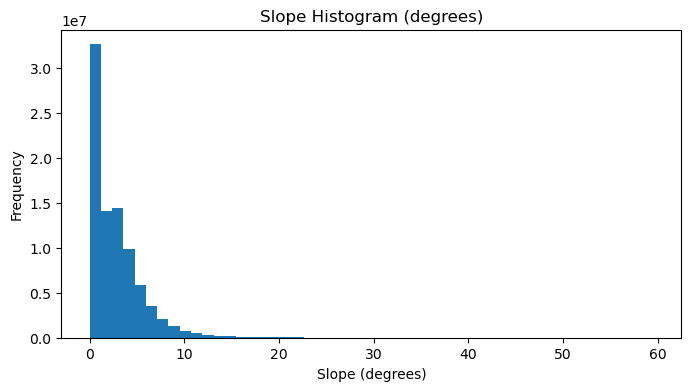

In [5]:
slope_clean = slope[slope != nodata]

plt.figure(figsize=(8,4))
plt.hist(slope_clean.flatten(), bins=50)
plt.title("Slope Histogram (degrees)")
plt.xlabel("Slope (degrees)")
plt.ylabel("Frequency")
plt.show()

In [6]:
max_val = np.nanmax(slope_clean)

slope_norm = slope / max_val
slope_norm[slope == nodata] = nodata

print("Normalized max:", np.nanmax(slope_norm))

Normalized max: 1.0


In [7]:
# add slope weight
slope_weighted = slope_norm * slope_weight
slope_weighted[slope == nodata] = nodata

print("Weighted max:", np.nanmax(slope_weighted))

Weighted max: 0.2


In [8]:
output_folder = "Norm"
os.makedirs(output_folder, exist_ok=True)

output_path = os.path.join(output_folder, "Slope_weighted.tif")

profile.update(dtype=rasterio.float32)

with rasterio.open(output_path, "w", **profile) as dst:
    dst.write(slope_weighted.astype(rasterio.float32), 1)

print("Saved:", output_path)

Saved: Norm/Slope_weighted.tif


# DTW

In [9]:
with rasterio.open("Layers/DTW_merged.tif") as src:
    dtw_mm = src.read(1).astype("float32")
    meta = src.meta.copy()

In [10]:
dtw_m = dtw_mm / 1000.0

In [11]:
meta.update(dtype="float32")

with rasterio.open("Layers/DTW_merged_meters.tif", "w", **meta) as dst:
    dst.write(dtw_m, 1)

In [12]:
print(np.nanmin(dtw_m), np.nanmax(dtw_m))

0.0 31.866


In [13]:
# normalize
dtw_norm = (dtw_m - np.nanmin(dtw_m)) / (np.nanmax(dtw_m) - np.nanmin(dtw_m))

0 → shallow groundwater (bad)

1 → deep groundwater (good)

In [14]:
dtw_weighted = dtw_norm * dtw_weight

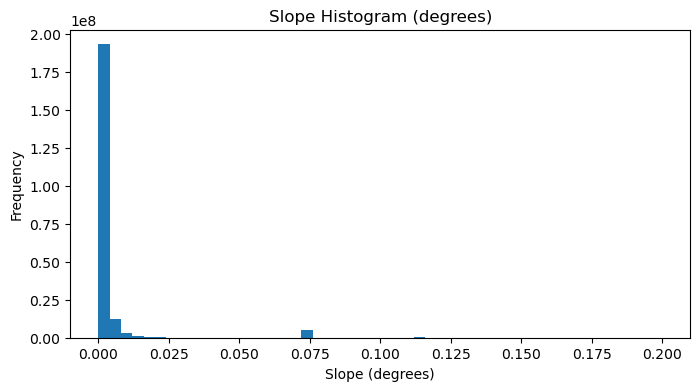

In [15]:
slope_clean = slope[slope != nodata]

plt.figure(figsize=(8,4))
plt.hist(dtw_weighted.flatten(), bins=50)
plt.title("Slope Histogram (degrees)")
plt.xlabel("Slope (degrees)")
plt.ylabel("Frequency")
plt.show()

In [16]:
meta.update(dtype="float32")  # ensure output type is float32

# Save weighted DTW raster
with rasterio.open("Norm/dtw_weighted.tif", "w", **meta) as dst:
    dst.write(dtw_weighted.astype("float32"), 1)

print("Done! DTW weighted raster saved.")

Done! DTW weighted raster saved.


# PEATLAND

In [17]:
with rasterio.open("Layers/Peatland_merge.tif") as src:
    peat = src.read(1).astype("float32")
    meta = src.meta.copy()

print("Peatland raster stats:")
print("Min:", np.nanmin(peat), "Max:", np.nanmax(peat))

Peatland raster stats:
Min: 0.0 Max: 4.0


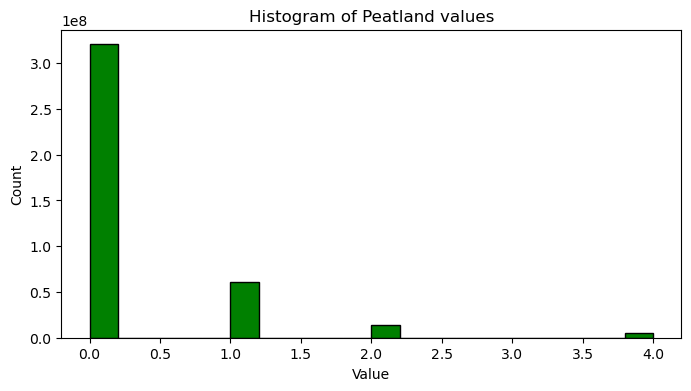

In [18]:
plt.figure(figsize=(8,4))
plt.hist(peat[~np.isnan(peat)].flatten(), bins=20, color='green', edgecolor='black')
plt.title("Histogram of Peatland values")
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()

In [19]:
# Peatland is categorical (1=peat, 0=no peat), normalize 0-1
peat_norm = peat / np.nanmax(peat)

In [20]:
# weight = 0.2  # example, adjust if needed
peat_weighted = peat_norm * peatland_weight

In [21]:
meta.update(dtype="float32")

with rasterio.open("Norm/peatland_weighted.tif", "w", **meta) as dst:
    dst.write(peat_weighted.astype("float32"), 1)

print("Done! Peatland layer normalized and weighted.")

Done! Peatland layer normalized and weighted.


# SUPERFICIAL DEPOSITS

In [22]:
with rasterio.open("Layers/SuperDeposits.tif") as src:
    deposits = src.read(1).astype("float32")
    meta = src.meta.copy()

print("Superficial Deposits raster stats:")
print("Min:", np.nanmin(deposits), "Max:", np.nanmax(deposits))

Superficial Deposits raster stats:
Min: 0.0 Max: 4.0


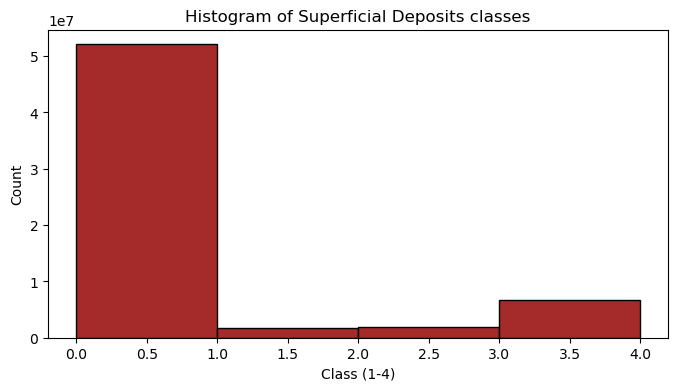

In [23]:
plt.figure(figsize=(8,4))
plt.hist(deposits[~np.isnan(deposits)].flatten(), bins=4, color='brown', edgecolor='black')
plt.title("Histogram of Superficial Deposits classes")
plt.xlabel("Class (1-4)")
plt.ylabel("Count")
plt.show()

In [24]:
deposits_norm = (deposits - 1) / (4 - 1)  # maps 1→0, 4→1

In [25]:
# deposits_weight = 0.2  # example weight for deposits
deposits_weighted = deposits_norm * deposits_weight

In [26]:
meta.update(dtype="float32")

with rasterio.open("Norm/superdeposits_weighted.tif", "w", **meta) as dst:
    dst.write(deposits_weighted.astype("float32"), 1)

print("Done! Superficial Deposits weighted raster saved.")

Done! Superficial Deposits weighted raster saved.


# CANOPY

In [27]:
with rasterio.open("Layers/CanopyCover.tif") as src:
    canopy = src.read(1).astype("float32")
    meta = src.meta.copy()

print("Canopy Cover raster stats:")
print("Min:", np.nanmin(canopy), "Max:", np.nanmax(canopy))

Canopy Cover raster stats:
Min: 0.0 Max: 127.0


In [28]:
# Clip values to 0-100%
canopy_clipped = np.clip(canopy, 0, 100)

In [29]:
print("Canopy Cover raster stats:")
print("Min:", np.nanmin(canopy_clipped), "Max:", np.nanmax(canopy_clipped))

Canopy Cover raster stats:
Min: 0.0 Max: 100.0


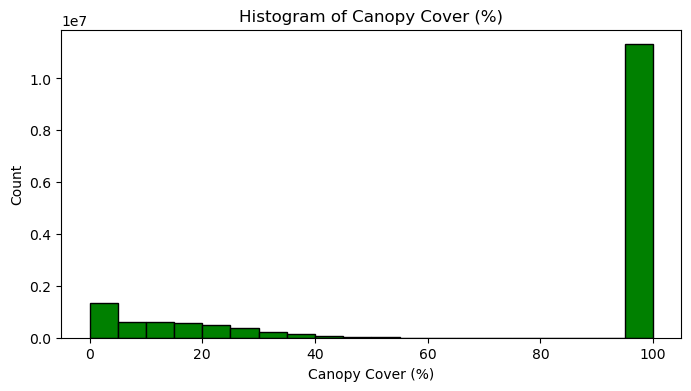

In [30]:
plt.figure(figsize=(8,4))
plt.hist(canopy_clipped[~np.isnan(canopy_clipped)].flatten(), bins=20, color='green', edgecolor='black')
plt.title("Histogram of Canopy Cover (%)")
plt.xlabel("Canopy Cover (%)")
plt.ylabel("Count")
plt.show()

In [31]:
canopy_norm = canopy_clipped / 100.0  # 0 → 0, 100 → 1

In [32]:
# canopy_weight = 0.2  # example weight for canopy
canopy_weighted = canopy_norm * canopy_weight 

In [33]:
meta.update(dtype="float32")

with rasterio.open("Norm/canopy_weighted.tif", "w", **meta) as dst:
    dst.write(canopy_weighted.astype("float32"), 1)

print("Done! Canopy Cover weighted raster saved.")

Done! Canopy Cover weighted raster saved.


# ROADS

In [34]:
with rasterio.open("Layers/Roads_10m.tif") as src:
    roads = src.read(1).astype("float32")
    meta = src.meta.copy()

print("Roads raster stats:")
print("Min:", np.nanmin(roads), "Max:", np.nanmax(roads))

Roads raster stats:
Min: 0.0 Max: 1.0


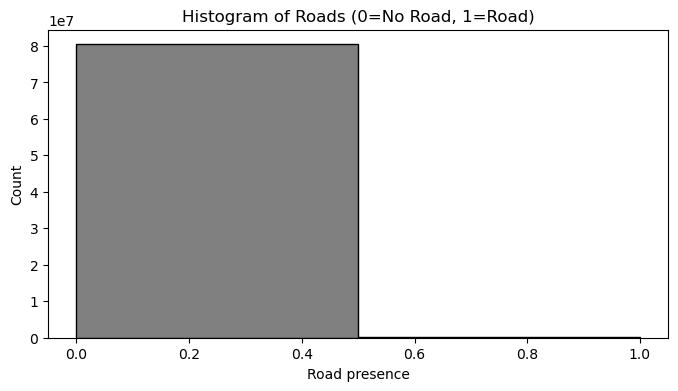

In [35]:
plt.figure(figsize=(8,4))
plt.hist(roads.flatten(), bins=2, color='gray', edgecolor='black')
plt.title("Histogram of Roads (0=No Road, 1=Road)")
plt.xlabel("Road presence")
plt.ylabel("Count")
plt.show()

In [36]:
roads_cost = 1 - roads  # Road=0 cost, no-road=1 cost

In [37]:
# road_weight = 0.2  # example weight for roads
roads_weighted = roads_cost * road_weight

In [38]:
meta.update(dtype="float32")

with rasterio.open("Norm/roads_weighted.tif", "w", **meta) as dst:
    dst.write(roads_weighted.astype("float32"), 1)

print("Done! Roads weighted raster saved.")

Done! Roads weighted raster saved.


# WATER

In [4]:
with rasterio.open("Layers/Water_10m.tif") as src:
    water = src.read(1).astype("float32")
    meta = src.meta.copy()

print("Water raster stats:")
print("Min:", np.nanmin(water), "Max:", np.nanmax(water))

Water raster stats:
Min: 0.0 Max: 1.0


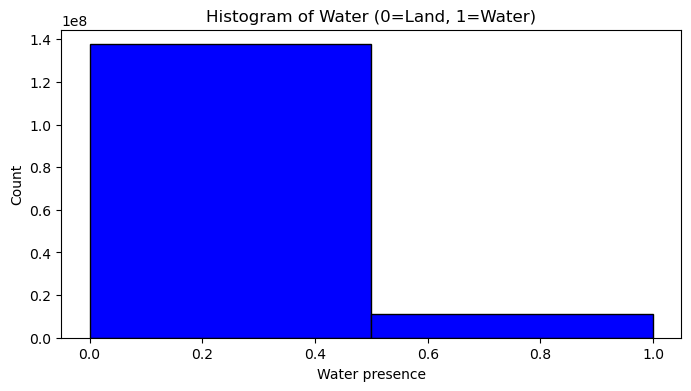

In [5]:
plt.figure(figsize=(8,4))
plt.hist(water.flatten(), bins=2, color='blue', edgecolor='black')
plt.title("Histogram of Water (0=Land, 1=Water)")
plt.xlabel("Water presence")
plt.ylabel("Count")
plt.show()

In [6]:
# water_cost = water.copy() 

In [7]:
# example weight for water
water_weighted = water * water_weight

In [8]:
meta.update(dtype="float32")

with rasterio.open("Norm/water_weighted.tif", "w", **meta) as dst:
    dst.write(water_weighted.astype("float32"), 1)

print("Done! Water weighted raster saved.")

Done! Water weighted raster saved.
